# Mapper para datos de COVID-19 siguiendo el artículo de Chen y Volić

En este notebook vamos a construir un grafo **Mapper** para datos de COVID-19 siguiendo la configuración descrita en el artículo:

> Yiran Chen e Ismar Volić, *Topological data analysis model for the spread of the coronavirus*, PLOS ONE, 2021.  
> https://doi.org/10.1371/journal.pone.0255584

La idea principal del artículo es representar cada registro como un punto en dimensión 4:

$$
(\text{Lat},\text{Long},\text{Date},\text{Cases}).
$$

Es decir, cada punto contiene información geográfica, temporal y epidemiológica:

- `Lat`: latitud.
- `Long`: longitud.
- `Date`: número de días transcurridos desde el inicio del registro.
- `Cases`: número acumulado de casos.

En este notebook **no usaremos solamente latitud y longitud**. Esa versión puede quedar en otro notebook. Aquí nos interesa replicar la construcción del artículo con las cuatro variables.


## 1. ¿Qué hace Mapper?

Mapper transforma una nube de puntos en un grafo.

De manera esquemática, el algoritmo hace lo siguiente:

1. Toma una nube de puntos $X$.
2. Aplica una función filtro, también llamada `lens`.
3. Cubre la imagen del filtro con intervalos o cubos traslapados.
4. Dentro de cada cubo, agrupa puntos usando un algoritmo de clustering.
5. Construye un grafo:
   - cada nodo representa un cluster local;
   - dos nodos se conectan si comparten al menos un punto.

En el artículo, la nube de datos vive en $\mathbb R^4$, porque se usan las cuatro variables:

$$
\text{Lat},\quad \text{Long},\quad \text{Date},\quad \text{Cases}.
$$

La ventaja de usar las cuatro variables es que el grafo no solo ve cercanía geográfica. También ve cercanía temporal y semejanza en el número de casos.


## 2. Configuración usada en el artículo

La configuración principal del artículo es:

- **Nube de datos:** puntos en $\mathbb R^4$ con coordenadas `(Lat, Long, Date, Cases)`.
- **Normalización:** cada coordenada se escala a norma unitaria.
- **Función filtro:** la identidad.
- **Cubrimiento:** cubos euclidianos en dimensión 4.
- **Número de cubos:** `n_cubes=10`.
- **Traslape:** `perc_overlap=0.08`, es decir, 8%.
- **Clustering:** DBSCAN.

La función filtro es la identidad:

$$
f:X\to X,\qquad f(x)=x.
$$

Esto significa que no se proyecta con PCA, t-SNE, UMAP ni otra técnica. El algoritmo usa directamente las cuatro coordenadas normalizadas.

El parámetro

```python
perc_overlap=0.08
```

significa que dos intervalos vecinos se traslapan un 8% de su ancho, medido por coordenada. No significa 8% del volumen total ni 8% de los puntos.


## 3. Pasos que seguiremos

En el notebook haremos estos pasos:

1. Importar las librerías necesarias.
2. Leer el archivo `.csv` con los datos.
3. Seleccionar las cuatro columnas del artículo: `Lat`, `Long`, `Date`, `Cases`.
4. Limpiar filas con valores faltantes.
5. Opcionalmente cortar el periodo de tiempo para acercarnos al periodo analizado en el artículo.
6. Normalizar cada columna a norma unitaria.
7. Definir la función filtro como la identidad.
8. Construir el grafo Mapper usando DBSCAN, `n_cubes=10` y `perc_overlap=0.08`.
9. Exportar la visualización a un archivo HTML interactivo.


## 4. Importación de librerías

Usaremos las siguientes librerías:

- `pandas`: para leer y manipular tablas de datos.
- `numpy`: para cálculos numéricos y normalización.
- `matplotlib`: para hacer gráficas exploratorias sencillas.
- `kmapper`: para construir el grafo Mapper.
- `DBSCAN` de `sklearn.cluster`: para hacer clustering local dentro de cada cubo del cubrimiento.
- `Path`: para manejar rutas de archivos de forma más cómoda.
- `IFrame` y `display`: para mostrar el archivo HTML dentro del notebook.

Si `kmapper` no está instalado, primero ejecuta:

```python
!pip install kmapper
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import IFrame, display

import contextlib
import io

import kmapper as km
from sklearn.cluster import DBSCAN


## 5. Lectura de los datos

El archivo que usaremos debe llamarse, preferentemente,

```python
data_preproccessed2.csv
```

El notebook buscará primero ese archivo en la misma carpeta donde esté guardado el notebook. También dejo algunas rutas alternativas por si estás trabajando dentro de este entorno.

El archivo debe contener las columnas:

```python
Lat, Long, Date, Cases
```

Si `Lat` aparece como índice en lugar de columna, el código la recupera automáticamente.


In [2]:
# Lista de rutas candidatas.
# La primera opción es la más importante: que el CSV esté en la misma carpeta que este notebook.
rutas_candidatas = [
    Path("data_preproccessed2.csv"),
    Path("data_preproccessed.csv"),
    Path("/mnt/data/mapper_covid_articulo_notebook/data_preproccessed2.csv"),
    Path("/mnt/data/mapper_covid_articulo_notebook/data_preproccessed.csv"),
]

ruta_datos = None
for ruta in rutas_candidatas:
    if ruta.exists():
        ruta_datos = ruta
        break

if ruta_datos is None:
    raise FileNotFoundError(
        "No encontré el archivo de datos. Coloca data_preproccessed2.csv "
        "en la misma carpeta que este notebook."
    )

print("Archivo usado:", ruta_datos)

# Leemos el archivo.
# Usamos index_col=0 porque en estos archivos la primera columna suele contener el índice del registro.
data_raw = pd.read_csv(ruta_datos, index_col=0)

# Si Lat quedó guardada como índice, la regresamos como columna.
if "Lat" not in data_raw.columns and data_raw.index.name == "Lat":
    data_raw = data_raw.reset_index()

# Si el índice no tiene nombre pero parece contener latitudes, también intentamos recuperarlo.
if "Lat" not in data_raw.columns:
    posible_lat = pd.to_numeric(data_raw.index, errors="coerce")
    if posible_lat.notna().mean() > 0.8:
        data_raw = data_raw.reset_index().rename(columns={"index": "Lat"})

data_raw.head()


Archivo usado: data_preproccessed2.csv


,Lat,Long,Date,Cases
Alabama 1/22/20,32.539527,-86.644082,0.0,0.0
Alabama 1/23/20,32.539527,-86.644082,1.0,0.0
Alabama 1/24/20,32.539527,-86.644082,2.0,0.0
Alabama 1/25/20,32.539527,-86.644082,3.0,0.0
Alabama 1/26/20,32.539527,-86.644082,4.0,0.0


## 6. Revisión rápida del archivo

Antes de construir Mapper, revisamos:

- cuántas filas y columnas tiene la tabla;
- qué nombres tienen las columnas;
- qué tipo de datos tiene cada columna;
- si hay valores faltantes.

Esto es importante porque Mapper trabaja con una matriz numérica. Si hay texto, valores vacíos o columnas mal nombradas, el algoritmo puede fallar.


In [3]:
print("Tamaño de la tabla:", data_raw.shape)
print("\nColumnas:")
print(data_raw.columns.tolist())
print("\nTipos de datos:")
print(data_raw.dtypes)
print("\nValores faltantes por columna:")
print(data_raw.isna().sum())


Tamaño de la tabla: (3397463, 4)

Columnas:
['Lat', 'Long', 'Date', 'Cases']

Tipos de datos:
Lat      float64
Long     float64
Date     float64
Cases    float64
dtype: object

Valores faltantes por columna:
Lat      0
Long     1
Date     1
Cases    1
dtype: int64


## 7. Selección de las cuatro variables del artículo

El artículo usa la nube de puntos en dimensión 4:

$$
(\text{Lat},\text{Long},\text{Date},\text{Cases}).
$$

Por eso seleccionamos únicamente esas cuatro columnas.

No hacemos aquí la versión solo con `Lat` y `Long`, porque esa versión solamente observa la geometría geográfica. El artículo busca mezclar:

- ubicación espacial: `Lat`, `Long`;
- evolución temporal: `Date`;
- crecimiento epidemiológico: `Cases`.


In [4]:
columnas_articulo = ["Lat", "Long", "Date", "Cases"]

faltantes = [col for col in columnas_articulo if col not in data_raw.columns]
if faltantes:
    raise ValueError(f"Faltan estas columnas necesarias: {faltantes}")

# Nos quedamos con las cuatro columnas y hacemos una copia independiente.
data_4d = data_raw[columnas_articulo].copy()

# Convertimos a número por seguridad.
# Si alguna entrada no se puede convertir, se vuelve NaN y se eliminará en el siguiente paso.
for col in columnas_articulo:
    data_4d[col] = pd.to_numeric(data_4d[col], errors="coerce")

# Eliminamos filas con valores faltantes.
data_4d = data_4d.dropna()

print("Tamaño después de seleccionar y limpiar las cuatro variables:", data_4d.shape)
data_4d.head()


Tamaño después de seleccionar y limpiar las cuatro variables: (3397462, 4)


,Lat,Long,Date,Cases
Alabama 1/22/20,32.539527,-86.644082,0.0,0.0
Alabama 1/23/20,32.539527,-86.644082,1.0,0.0
Alabama 1/24/20,32.539527,-86.644082,2.0,0.0
Alabama 1/25/20,32.539527,-86.644082,3.0,0.0
Alabama 1/26/20,32.539527,-86.644082,4.0,0.0


## 8. Corte temporal para acercarnos al periodo del artículo

En el artículo, una de las visualizaciones principales corresponde a los datos reportados hasta el 19 de junio de 2020. Si `Date=0` corresponde al 22 de enero de 2020, entonces el 19 de junio de 2020 corresponde aproximadamente al día 149.

Por eso dejo activado el corte:

```python
USAR_CORTE_TEMPORAL = True
DIA_MAX = 149
```

Si quieres usar todos tus datos, cambia `USAR_CORTE_TEMPORAL` a `False`.

Si quieres usar el corte de 170 días que aparecía en el otro notebook, cambia `DIA_MAX = 170`.


In [5]:
USAR_CORTE_TEMPORAL = True
DIA_MAX = 149

if USAR_CORTE_TEMPORAL:
    data_4d = data_4d[data_4d["Date"] <= DIA_MAX].copy()

print("Tamaño después del corte temporal:", data_4d.shape)
print("Rango de Date:", data_4d["Date"].min(), "a", data_4d["Date"].max())
data_4d.head()


Tamaño después del corte temporal: (445950, 4)
Rango de Date: 0.0 a 149.0


,Lat,Long,Date,Cases
Alabama 1/22/20,32.539527,-86.644082,0.0,0.0
Alabama 1/23/20,32.539527,-86.644082,1.0,0.0
Alabama 1/24/20,32.539527,-86.644082,2.0,0.0
Alabama 1/25/20,32.539527,-86.644082,3.0,0.0
Alabama 1/26/20,32.539527,-86.644082,4.0,0.0


## 9. Exploración básica de las variables

Antes de normalizar, conviene ver los rangos de las variables.

Esto es importante porque las cuatro columnas están en escalas muy distintas. Por ejemplo:

- `Lat` y `Long` están en grados geográficos;
- `Date` está en días;
- `Cases` puede tomar valores mucho más grandes.

Si no normalizamos, la variable con valores numéricos más grandes puede dominar las distancias.


In [6]:
data_4d.describe().T


,count,mean,std,min,25%,50%,75%,max
Lat,445950.0,36.398599,9.075460,-14.2710,33.385709,37.692001,41.334451,69.314792
Long,445950.0,-89.014501,21.655974,-174.1596,-98.020991,-90.213303,-83.330352,145.673900
Date,445950.0,74.500000,43.300356,0.0000,37.000000,74.500000,112.000000,149.000000
Cases,445950.0,222.973340,1951.416319,0.0000,0.000000,1.000000,24.000000,86551.000000


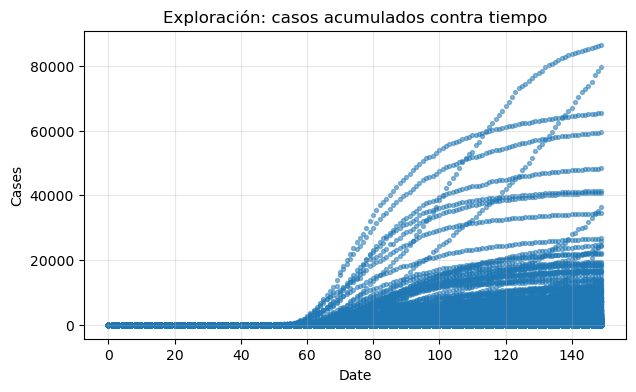

In [7]:
# Gráfica exploratoria sencilla: casos acumulados contra tiempo.
# Esta gráfica no es Mapper; solo sirve para ver la escala de las variables.
plt.figure(figsize=(7, 4))
plt.scatter(data_4d["Date"], data_4d["Cases"], s=8, alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Cases")
plt.title("Exploración: casos acumulados contra tiempo")
plt.grid(alpha=0.3)
plt.show()


## 10. Normalización a norma unitaria

El artículo normaliza cada coordenada por separado. Es decir, toma cada columna y la divide entre su norma euclidiana.

Si una columna es

$$
v=(v_1,v_2,\dots,v_n),
$$

entonces la reemplazamos por

$$
\frac{v}{\|v\|}.
$$

Esto hace que cada variable tenga norma 1 como vector columna. La normalización no significa que todos los valores queden entre 0 y 1. Significa que la norma completa de la columna queda igual a 1.

Esta normalización busca que `Lat`, `Long`, `Date` y `Cases` tengan pesos comparables al calcular distancias.


In [8]:
def normalizar_columnas_norma_unitaria(df):
    # Normaliza cada columna numérica dividiéndola entre su norma euclidiana.
    # Si una columna tiene norma cero, se deja igual para evitar división entre cero.
    df_norm = df.copy().astype(float)

    for col in df_norm.columns:
        norma = np.linalg.norm(df_norm[col].values)
        if norma != 0:
            df_norm[col] = df_norm[col] / norma

    return df_norm


data_4d_normalizado = normalizar_columnas_norma_unitaria(data_4d)

data_4d_normalizado.head()


,Lat,Long,Date,Cases
Alabama 1/22/20,0.001299,-0.001416,0.000000,0.0
Alabama 1/23/20,0.001299,-0.001416,0.000017,0.0
Alabama 1/24/20,0.001299,-0.001416,0.000035,0.0
Alabama 1/25/20,0.001299,-0.001416,0.000052,0.0
Alabama 1/26/20,0.001299,-0.001416,0.000070,0.0


In [9]:
# Verificamos que cada columna normalizada tenga norma aproximadamente 1.
normas = np.linalg.norm(data_4d_normalizado.values, axis=0)

pd.DataFrame({
    "columna": columnas_articulo,
    "norma después de normalizar": normas
})


,columna,norma después de normalizar
0,Lat,1.0
1,Long,1.0
2,Date,1.0
3,Cases,1.0


## 11. Función filtro: identidad

En Mapper, la función filtro se suele llamar `lens`.

En muchos ejemplos se usa PCA, t-SNE, UMAP o alguna función estadística. Pero en este artículo no se hace eso.

Aquí la función filtro es la identidad:

$$
f:X\to X,\qquad f(x)=x.
$$

En código esto significa que:

```python
lens = X
```

Como nuestros datos ya están normalizados, usaremos:

```python
X = data_4d_normalizado.values
lens = X
```

Esto quiere decir que Mapper construirá el cubrimiento directamente en las cuatro coordenadas normalizadas.


In [10]:
X = data_4d_normalizado.values
lens = X.copy()

print("Forma de X:", X.shape)
print("Forma de lens:", lens.shape)


Forma de X: (445950, 4)
Forma de lens: (445950, 4)


## 12. Cubrimiento usado en el artículo

El artículo usa cubos euclidianos en dimensión 4 con:

```python
n_cubes=10
perc_overlap=0.08
```

Como estamos en dimensión 4, esto significa que cada eje se cubre con 10 intervalos traslapados. Después se toman productos cartesianos de intervalos para formar cubos en $\mathbb R^4$.

El traslape `perc_overlap=0.08` significa que intervalos vecinos se traslapan un 8% de su ancho por coordenada.

No significa:

- 8% del volumen total;
- 8% de los datos;
- 8% de los nodos.

Significa 8% del ancho de los intervalos vecinos en cada dirección coordenada.


In [ ]:
cover_articulo = km.Cover(
    n_cubes=10,
    perc_overlap=0.08
)


## 13. Clustering local con DBSCAN

Después de cubrir la nube, Mapper toma la preimagen de cada cubo y hace clustering dentro de esa región.

El artículo usa DBSCAN. DBSCAN es útil porque puede detectar clusters con formas no necesariamente convexas.

Aquí escribimos explícitamente:

```python
DBSCAN(eps=0.5, min_samples=3)
```

porque esos son los valores por defecto que usa KeplerMapper cuando no se especifica otro clusterer. Es decir, esto reproduce el DBSCAN por defecto de KeplerMapper de forma explícita.

Si escribes solamente:

```python
DBSCAN()
```

entonces usas el default de `scikit-learn`, que normalmente tiene `min_samples=5`. Eso puede cambiar el grafo.


In [ ]:
clusterer_articulo = DBSCAN(
    eps=0.5,
    min_samples=3
)


## 14. Construcción del grafo Mapper

Ahora construimos el grafo Mapper.

Usamos:

- `lens = X`, porque el filtro es la identidad;
- `X`, porque queremos clusterizar en el mismo espacio normalizado;
- `cover_articulo`, con 10 cubos y 8% de traslape;
- `clusterer_articulo`, que es DBSCAN.

Además ponemos:

```python
verbose=0
```

para que KeplerMapper no imprima demasiada información mientras corre.


In [ ]:
mapper = km.KeplerMapper(verbose=0)

# Redirigimos la salida de texto para mantener limpio el notebook.
# Esto no cambia el resultado; solo evita que se impriman muchos mensajes.
with contextlib.redirect_stdout(io.StringIO()):
    graph = mapper.map(
        lens,
        X,
        clusterer=clusterer_articulo,
        cover=cover_articulo
    )

print("Mapper construido.")
print("Número de nodos:", len(graph["nodes"]))


## 15. Resumen del grafo

El objeto `graph` es un diccionario con la información del grafo Mapper.

Las partes más importantes son:

- `graph["nodes"]`: nodos del grafo. Cada nodo contiene los índices de los puntos que forman un cluster local.
- `graph["links"]`: aristas del grafo. Dos nodos se conectan si comparten puntos.
- `graph["meta"]`: información adicional sobre parámetros y construcción.

A continuación calculamos un resumen simple.


In [ ]:
def resumen_grafo_mapper(graph):
    # Calcula un resumen básico de un grafo Mapper producido por KeplerMapper.
    nodos = graph.get("nodes", {})
    links = graph.get("links", {})

    # Contamos aristas sin repetir.
    aristas = set()
    for nodo, vecinos in links.items():
        for vecino in vecinos:
            aristas.add(tuple(sorted([nodo, vecino])))

    tamanios = [len(indices) for indices in nodos.values()]

    resumen = {
        "nodos": len(nodos),
        "aristas": len(aristas),
        "tamaño mínimo de nodo": np.min(tamanios) if tamanios else 0,
        "tamaño promedio de nodo": np.mean(tamanios) if tamanios else 0,
        "tamaño máximo de nodo": np.max(tamanios) if tamanios else 0,
    }

    return pd.DataFrame([resumen])


resumen_grafo_mapper(graph)


## 16. Preparación de etiquetas para la visualización

KeplerMapper exporta el resultado a un archivo HTML interactivo.

Para que sea más fácil explorar el grafo, crearemos etiquetas que aparezcan al inspeccionar los nodos.

Cada etiqueta contendrá:

- el índice original del registro;
- latitud;
- longitud;
- día;
- casos acumulados.


In [ ]:
# Creamos una tabla auxiliar para construir tooltips.
tabla_tooltips = data_4d.copy()
tabla_tooltips["registro"] = tabla_tooltips.index.astype(str)

custom_tooltips = tabla_tooltips.apply(
    lambda r: (
        f"{r['registro']} | "
        f"Lat={r['Lat']:.4f}, "
        f"Long={r['Long']:.4f}, "
        f"Date={r['Date']:.0f}, "
        f"Cases={r['Cases']:.0f}"
    ),
    axis=1
).values

custom_tooltips[:5]


## 17. Exportación a HTML

El resultado se guardará en un archivo HTML interactivo.

En este archivo puedes hacer zoom, mover nodos y revisar qué puntos caen en cada nodo.

El color de los nodos se puede usar para explorar alguna variable. Aquí usamos `Cases` como valor de color, para que sea más fácil detectar regiones con mayor número acumulado de casos.

Importante: en el artículo los autores mencionan que los colores no tienen un significado matemático profundo; son principalmente una ayuda visual.


In [ ]:
html_salida = "mapper_covid_articulo_4D.html"

kwargs_visualizacion = dict(
    path_html=html_salida,
    title="Mapper COVID-19 en R4: Lat, Long, Date y Cases",
    color_values=data_4d["Cases"].values,
    color_function_name="Casos acumulados",
    lens=lens,
    lens_name=columnas_articulo,
    X=X,
    X_names=[f"{col} normalizado" for col in columnas_articulo],
    include_searchbar=True,
)

# Algunas versiones de KeplerMapper usan custom_tooltips y otras custom_tooltip.
# Probamos primero con custom_tooltips; si la versión instalada usa el nombre singular,
# hacemos el segundo intento.
try:
    mapper.visualize(
        graph,
        custom_tooltips=custom_tooltips,
        **kwargs_visualizacion
    )
except TypeError:
    mapper.visualize(
        graph,
        custom_tooltip=custom_tooltips,
        **kwargs_visualizacion
    )

print("Archivo HTML creado:", html_salida)


## 18. Mostrar el HTML dentro del notebook

Si estás trabajando en Jupyter, la siguiente celda intenta mostrar la visualización directamente dentro del notebook.

Si no se muestra, abre manualmente el archivo:

```python
mapper_covid_articulo_4D.html
```

en tu navegador.


In [ ]:
display(IFrame(src=html_salida, width="100%", height=750))


# 19. Interpretación básica

#### Este Mapper no debe interpretarse como un mapa geográfico común.

#### Cada nodo representa un cluster local de puntos parecidos respecto a las cuatro variables:

$$
{\Large \text{Lat},\quad \text{Long},\quad \text{Date},\quad \text{Cases}.}
$$

#### Por eso, dos registros pueden estar cerca en el grafo si son parecidos en ubicación, tiempo y número de casos. En cambio, dos registros geográficamente cercanos pueden separarse si corresponden a momentos distintos o a números de casos muy diferentes.

#### En el artículo, las ramas o componentes del grafo se interpretan como estructuras que pueden reflejar brotes, regiones destacadas o cambios temporales importantes en la pandemia.

#### La interpretación debe hacerse revisando los puntos que caen en cada nodo. Para eso sirven los tooltips y la tabla de puntos dentro del HTML interactivo.


## 20. Comentarios sobre los parámetros

La construcción principal del artículo usa:

```python
n_cubes=10
perc_overlap=0.08
```

Estos parámetros controlan el cubrimiento.

- Si aumentamos `n_cubes`, el cubrimiento es más fino y el grafo puede fragmentarse más.
- Si disminuimos `n_cubes`, el cubrimiento es más grueso y el grafo puede volverse más compacto.
- Si aumentamos `perc_overlap`, hay más puntos compartidos entre cubos vecinos y pueden aparecer más conexiones.
- Si disminuimos `perc_overlap`, hay menos puntos compartidos y el grafo puede desconectarse más.

Para replicar el artículo, dejamos los valores:

```python
n_cubes=10
perc_overlap=0.08
```

pero después se puede experimentar con otros valores para ver cómo cambia el grafo.


## 21. Ejercicio opcional. 

Podríamos cambiar `n_cubes` o `perc_overlap` y guardar otra visualización HTML.


In [ ]:

# cover_experimento = km.Cover(n_cubes=15, perc_overlap=0.15)
#
# with contextlib.redirect_stdout(io.StringIO()):
#     graph_experimento = mapper.map(
#         lens,
#         X,
#         clusterer=clusterer_articulo,
#         cover=cover_experimento
#     )
#
# mapper.visualize(
#     graph_experimento,
#     path_html="mapper_covid_experimento.html",
#     title="Mapper COVID-19: experimento con otros parámetros",
#     color_values=data_4d["Cases"].values,
#     color_function_name="Casos acumulados"
# )
